**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 01. Distribution Fitting
Now we will take a look at fitting distributions to data in BestFit.

## What You'll Learn
- Data types used in BestFit
- Probability distributions commonly used in flood frequency analysis
- Running BestFit's `FittingAnalysis`
- How to rank candidate distributions
- Interpret fitted return levels with diagnostics 

## Set Up

In [2]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit import ExactData, ExactSeries
from RMC.BestFit.Models import DataFrame, UnivariateDistribution
from RMC.BestFit.Analyses import FittingAnalysis
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod

from Numerics.Distributions import (UnivariateDistributionType, Exponential, GammaDistribution, GeneralizedExtremeValue, GeneralizedLogistic, GeneralizedNormal,
GeneralizedPareto, Gumbel, KappaFour, LnNormal, Logistic, LogNormal, LogPearsonTypeIII, Normal, PearsonTypeIII, Weibull)

print("✓ Imported namespaces successfully")

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll
✓ Imported namespaces successfully


## Data Types
Before we get started with our distributions, we will explore the different data types. There are four data types, each with their own collection in the BestFit DataFrame.

- ExactData: Exact observations (point values with known magnitude) 
- UncertainData: Uncertain observations (values with measurement error distributions)
- IntervalData: Interval-censored observations (bounded ranges)
- ThresholdData: Threshold data (perception thresholds with exceedance counts).

Each of these are associated with a series: ExactSeries, UncertainSeries, IntervalSeries, and ThresholdSeries. In notebook 00 we used the ExactData object to create an ExactSeries in our DataFrame. We will most commonly use ExactSeries throughout this demo, but it is important to be aware of all of the data types that BestFit can handle.

## Probability Distributions to Compare

The probability distributions in BestFit come from the Numerics library. The Numerics library holds 40+ distributions. BestFit focuses primarily on the 15 most commonly used in flood frequency analysis. We will take a quick look at these distributions before we take a look at the Distribution Fitting Analysis.

| Distribution | Parameters | Typical Use |
|--------------|------------|-------------|
| Exponential | 2 | Peaks-over-threshold excesses |
| Gamma | 3 | Precipitation, positive-valued data |
| GEV | 3 | Annual maxima (international standard) |
| Generalized Logistic | 3 | UK FEH standard |
| Generalized Normal | 3 | Symmetric with flexible kurtosis |
| Generalized Pareto | 3 | Threshold excesses |
| Gumbel | 2 | Annual maxima (light tail) |
| Kappa Four | 4 | Very flexible, research use |
| Ln-Normal | 2 | Right-skewed data |
| Logistic | 2 | Growth curves |
| Log-Normal | 2 | Multiplicative processes |
| Log-Pearson Type III | 3 | Bulletin 17C standard (US) |
| Normal | 2 | Symmetric data, transformed flows |
| Pearson Type III | 3 | Skewed data |
| Weibull | 3 | Minima, wind speeds |


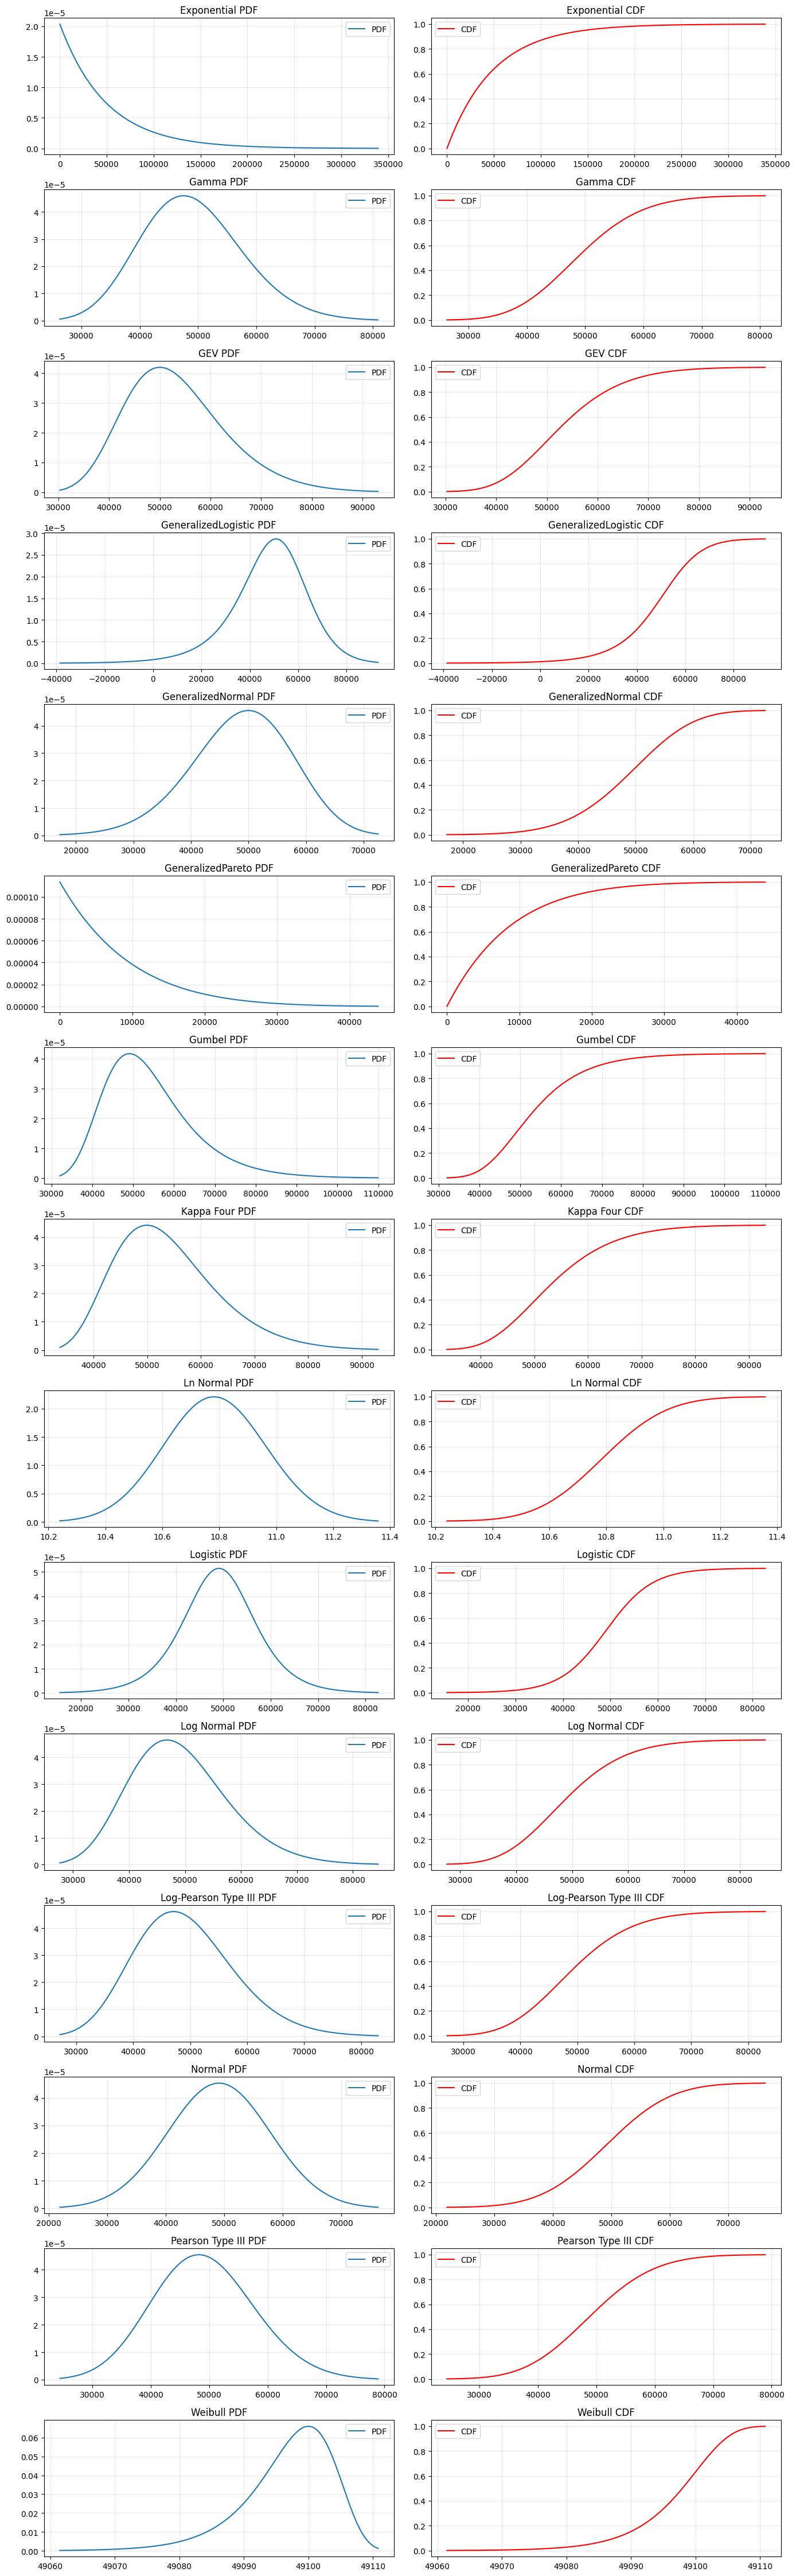

In [ ]:
# Synthetic data
annual_peaks = np.array([
    45000, 52000, 38000, 61000, 49000, 55000, 42000, 67000, 39000, 48000,
    51000, 36000, 58000, 44000, 53000, 47000, 62000, 41000, 50000, 37000,
    54000, 46000, 59000, 43000, 56000, 40000, 63000, 35000, 57000, 45000
], dtype=float)

# Create our DataFrame
df = DataFrame()
for i, q in enumerate(annual_peaks):
    df.ExactSeries.Add(ExactData(1999 + i, float(q)))
df.PlottingParameter = 0.0
df.CalculatePlottingPositions()

mu = float(np.mean(annual_peaks))
sd = float(np.std(annual_peaks, ddof=1))
skew = float(pd.Series(annual_peaks).skew())

specs = {
    "Exponential": Exponential(0.0, mu),
    "Gamma": GammaDistribution(sd**2 / mu, mu**2 / sd**2),
    "GEV": GeneralizedExtremeValue(mu, sd, 0.1),
    "GeneralizedLogistic": GeneralizedLogistic(mu, sd, 0.1),
    "GeneralizedNormal": GeneralizedNormal(mu, sd, 0.1), 
    "GeneralizedPareto": GeneralizedPareto(0.0, sd, 0.1),
    "Gumbel": Gumbel(mu, sd),
    "Kappa Four": KappaFour(mu, sd, 0.1, 0.1),
    "Ln Normal": LnNormal(np.mean(np.log(annual_peaks)), np.std(np.log(annual_peaks), ddof=1)),
    "Logistic": Logistic(mu, sd*np.sqrt(3)/np.pi),
    "Log Normal": LogNormal(np.mean(np.log10(annual_peaks)), np.std(np.log10(annual_peaks), ddof=1)),
    "Log-Pearson Type III": LogPearsonTypeIII(np.mean(np.log10(annual_peaks)), np.std(np.log10(annual_peaks), ddof=1), pd.Series(np.log10(annual_peaks)).skew()),
    "Normal": Normal(mu, sd),
    "Pearson Type III": PearsonTypeIII(mu, sd, skew),  
    "Weibull": Weibull(mu, sd)
}

fig, axes = plt.subplots(len(specs), 2, figsize=(14, 3 * len(specs)))

for i, (name, dist) in enumerate(specs.items()):
    xmin = dist.InverseCDF(0.001)
    xmax = dist.InverseCDF(0.999)
    x = np.linspace(xmin, xmax, 400)

    y_pdf = np.array([dist.PDF(v) for v in x])
    y_cdf = np.array([dist.CDF(v) for v in x])

    axes[i, 0].plot(x, y_pdf, label="PDF")
    # Uncomment the line below to show the histogram of the observed data as a density overlay
    # axes[i, 0].hist(annual_peaks, bins = 15, range = (xmin, xmax), density=True, alpha=0.5, color='gray', label = "Data (Density)")
    axes[i, 0].set_title(f"{name} PDF")
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].legend()

    axes[i, 1].plot(x, y_cdf, "r-", label="CDF")
    axes[i, 1].set_title(f"{name} CDF")
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

## Distribution Fitting Analysis
The Distribution `FittingAnalysis` is a powerful tool that automatically fits all 15 supported univariate distributions to a dataset, ranks them by goodness-of-fit criteria, and provides a comparative summary for model selection. This is often the first step in flood frequency analysis — quickly surveying which distribution families best describe the data before conducting detailed Bayesian analysis on selected candidates.

### Why Automated Fitting Matters

Consider a hydrologist analyzing 50 years of annual peak flows at a new site. Which distribution should be used?

- **Log-Pearson Type III** is the Bulletin 17C standard in the United States
- **Generalized Extreme Value (GEV)** is widely used internationally
- **Generalized Logistic** is the UK Flood Estimation Handbook standard
- Regional guidance might suggest other options

Rather than fitting each distribution manually, `FittingAnalysis` fits all 15 in parallel and produces a ranked comparison. This reveals:

1. Which distributions fit the data well
2. Which produce similar vs. different estimates
3. Whether the data have unusual features (heavy tails, bimodality)

### Mathematical Background

#### Maximum Likelihood Fitting

For each distribution, `FittingAnalysis` finds the parameters that maximize the log-likelihood:

```math
\hat{\theta} = \arg\max_{\theta} \ell(\theta) = \arg\max_{\theta} \sum_{i=1}^{n} \log f(y_i | \theta)
```

where $f(y | \theta)$ is the probability density function parameterized by $\theta$.

#### Model Comparison Criteria

To compare models with different numbers of parameters, we use information criteria that penalize complexity:

##### Akaike Information Criterion (AIC)

```math
\text{AIC} = -2\ell(\hat{\theta}) + 2k
```

where $k$ is the number of parameters. AIC estimates the expected Kullback-Leibler divergence from the true distribution. **Lower AIC is better.**

##### Bayesian Information Criterion (BIC)

```math
\text{BIC} = -2\ell(\hat{\theta}) + k \log(n)
```

BIC penalizes complexity more heavily than AIC for $n > 7$. It's consistent — selecting the true model as $n \to \infty$ if it's among the candidates.

##### Root Mean Square Error (RMSE)

RMSE measures the average deviation between observed and predicted quantiles at the plotting positions:

```math
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(y_i - F^{-1}(p_i | \hat{\theta})\right)^2}
```

where $p_i$ is the plotting position for observation $i$ and $F^{-1}$ is the inverse CDF (quantile function).


## Basic Example
Let's do a basic example of how we can use the Distribution Fitting Analysis.

In [ ]:
# Create DataFrame with flood data
annual_peaks = [
    45000, 52000, 38000, 61000, 49000, 55000, 42000, 67000, 39000, 48000,
    51000, 36000, 58000, 44000, 53000, 47000, 62000, 41000, 50000, 37000,
    54000, 46000, 59000, 43000, 56000, 40000, 63000, 35000, 57000, 45000
]
df = DataFrame()
df.ExactSeries = ExactSeries(convert_to_dotnet_array(annual_peaks))

analysis = FittingAnalysis(df)
# In C# this command is usually just analysis.RunAsync()
# However, in Python we have to add the .Wait() to the end because (!! WHY? !!)
analysis.RunAsync().Wait()

print("Distribution Fitting Results (ranked by AIC):")
print(f'{"Rank":<6} {"Distribution":<25} {"AIC":>12} {"BIC":>12} {"RMSE":>12}')

# Access our results
ranked = sorted(
    analysis.FittedDistributions,
    key=lambda fd: fd.AIC       # !!! EXPLAIN THIS LINE !!!
)

for i, fd in enumerate(ranked, start=1):
    print(f" {i:<6} {str(fd.Distribution.Type):<25} {fd.AIC:12.2f} {fd.BIC:12.2f} {fd.RMSE:12.4f}")

Distribution Fitting Results (ranked by AIC):
Rank   Distribution                       AIC          BIC         RMSE
 1      GeneralizedPareto               627.51       631.71   19920.3294
 2      GammaDistribution               632.57       635.38          inf
 3      LogNormal                       632.62       635.42          inf
 4      LnNormal                        632.62       635.42          inf
 5      Normal                          633.11       635.91          inf
 6      Gumbel                          633.49       636.29          inf
 7      GeneralizedExtremeValue         634.13       638.34   32267.1864
 8      Weibull                         634.29       637.09          inf
 9      PearsonTypeIII                  634.31       638.52          inf
 10     LogPearsonTypeIII               634.52       638.72  125046.5350
 11     GeneralizedNormal               634.62       638.82          inf
 12     Logistic                        635.33       638.14          inf
 13   

We can access the best-fitting distribution parameters like so.

In [ ]:
# Best fitting distribution according to AIC 
best = sorted(analysis.FittedDistributions, key=lambda fd: fd.AIC)[0]

print(f"Best-Fitting Distribution: {best.Distribution.Type}")   

for name, param in zip(best.Distribution.ParameterNames, best.Distribution.GetParameters):
    print(f"  {name}: {param:.4f}")

Best-Fitting Distribution: GeneralizedPareto
  Location (ξ): 35000.0000
  Scale (α): 25164.9241
  Shape (κ): 0.7748


We can get the return levels from the best-fitting distribution.

!!! Explain return levels !!!

Return Level Estimates for Best Distribution:
Return Period      Return Level
2                      48496.28
5                      58146.33
10                     62024.96
25                     64798.24
50                     65912.91
100                    66564.41
200                    66945.21
500                    67217.48


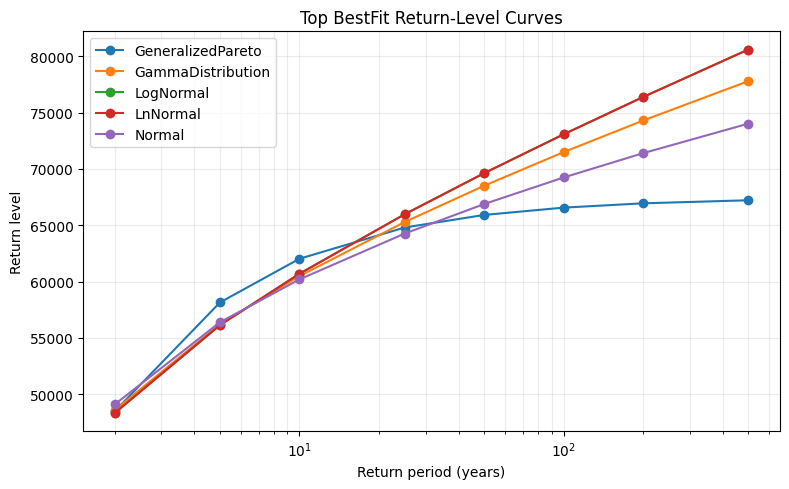

Exception in callback BaseAsyncIOLoop._handle_events()
handle: <Handle BaseAsyncIOLoop._handle_events()>
Traceback (most recent call last):
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\asyncio\events.py", line 89, in _run
    self._context.run(self._callback, *self._args)
    ~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\tornado\platform\asyncio.py", line 208, in _handle_events
    handler_func(fileobj, events)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py", line 600, in _handle_events
    self._handle_recv()
    ~~~~~~~~~~~~~~~~~^^
  File "c:\Users\q0rmcssn\AppData\Local\Programs\Python\Python313\Lib\site-packages\zmq\eventloop\zmqstream.py", line 629, in _handle_recv
    self._run_callback(callback, msg)
    ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\q0rmcssn\AppData\Loc

In [ ]:
return_period_grid = np.array([2,5,10,25,50,100,200,500], dtype=float)

plt.figure(figsize=(8,5))

# Plot the return levels for the best 5 distributions
for fd in ranked[:5]:
    plt.plot(return_period_grid, [fd.Distribution.InverseCDF(float(1-1/t)) for t in return_period_grid], marker="o", label=str(fd.Distribution.Type))
    
plt.xscale("log")
plt.xlabel("Return period (years)")
plt.ylabel("Return level")
plt.title("Top BestFit Return-Level Curves")
plt.grid(alpha=.25, which="both"); plt.legend()
plt.tight_layout()

print("Return Level Estimates for Best Distribution:")
print(f'{"Return Period":<15} {"Return Level":>15}')

for T in return_periods:
    p = 1 - 1/T # exceedance probability for return period T
    return_level = best.Distribution.InverseCDF(p)
    print(f"{T:<15} {return_level:>15.2f}")

## Understanding Our Results

### AIC Differences

The magnitude of AIC differences matters:

| ΔAIC from Best | Interpretation |
|----------------|----------------|
| 0-2 | Substantial support, essentially equivalent |
| 2-4 | Some support, consider both models |
| 4-7 | Considerably less support |
| > 10 | Essentially no support |

If multiple distributions have ΔAIC < 2, consider model averaging or conducting detailed Bayesian analysis on all of them.

### When Results Disagree

Sometimes AIC and BIC select different models:
- **AIC** tends to select more complex models (lower penalty)
- **BIC** tends to select simpler models (higher penalty for complexity)

If they disagree substantially, the data may not strongly favor any particular model. Consider:
1. Using model averaging (weighted by AIC weights)
2. Conducting sensitivity analysis with multiple distributions
3. Using physical reasoning to select

### Warning Signs

Watch for these issues in the fitting results:

| Issue | Possible Cause |
|-------|----------------|
| Many distributions fail to converge | Unusual data, outliers, wrong units |
| Very different AIC among similar distributions | Boundary effects, numerical issues |
| Shape parameter at bound | Distribution may not be appropriate |
| Extremely low RMSE for complex model | Possible overfitting |


## Best Practices

### 1. Start with FittingAnalysis

Before detailed Bayesian analysis (which we will discuss in notebook 03), run `FittingAnalysis` to:
- Survey which distributions fit well
- Identify data issues (outliers, wrong units)
- Guide distribution selection

### 2. Don't Blindly Trust AIC

AIC identifies the best-fitting model among candidates, but:
- The true distribution may not be among the 15 candidates
- Physical reasoning should inform selection
- Regulatory requirements may mandate specific distributions

### 3. Check Tail Behavior

Different distributions can fit the bulk of the data similarly but differ dramatically in the tails. Compare 100-year and 500-year return levels

In [7]:
print("100-year and 500-year Return Levels:")
print(f"{"Distribution":<25} {"RL-100":>12} {"RL-500":>12}")

for fd in ranked[:5]:  # Show top 5 distributions
    rl_100 = fd.Distribution.InverseCDF(1 - 1/100)
    rl_500 = fd.Distribution.InverseCDF(1 - 1/500)
    print(f"{str(fd.Distribution.Type):<25} {rl_100:>12.2f} {rl_500:>12.2f}")

100-year and 500-year Return Levels:
Distribution                    RL-100       RL-500
GeneralizedPareto             66564.41     67217.48
GammaDistribution             71492.75     77792.45
LogNormal                     73073.95     80600.44
LnNormal                      73073.35     80599.85
Normal                        69240.83     74018.26


### 4. Follow Up with Bayesian Analysis
`FittingAnalysis` provides point estimates only. For uncertainty quantification, we follow up with `UnivariateAnalysis` (Bayesian Analysis) which we will cover in notebook 03.

## Summary 
In this notebook you

$\checkmark$ Explored the data types offered in BestFit     
$\checkmark$ Graphed the most common distributions used in flood frequency analysis     
$\checkmark$ Fit the 15 most common distributions to data all at once       
$\checkmark$ Compared the different accuracy metrics for a model's fit      

## Exercises
1. Generate a synthetic dataset (using Numerics GenerateRandomValues() or a Python method)
2. Run a `FittingAnalysis` on the the data
3. Extract the best distribution and it's parameters